In [1]:
import os, sys

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
sys.path.insert(0, curdir+"/../data_processing")
from ceres_ebaf import slice_dataset_with_year_and_month
plt.rcParams['figure.figsize'] = [10, 3.5]

In [2]:
days_in_four_years = 365*3+366
period = days_in_four_years / 4
hours = np.linspace(0,days_in_four_years+365,(days_in_four_years+365)*24)
days_from_jan_to_equinox = 31+28+21

# Sine wave starts at equinox
calendar_start = 0.5*np.sin((hours-24*days_from_jan_to_equinox)*2*np.pi/period)
print(np.average(calendar_start))

5.698936152780896e-05


In [3]:
print("hello")

hello


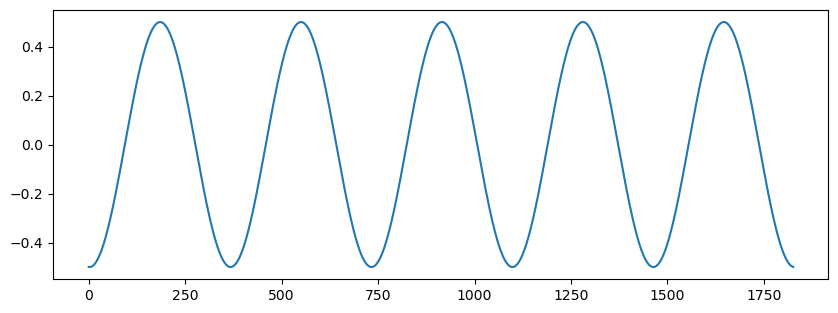

In [4]:
plt.plot(hours, calendar_start)

In [5]:
# Use CERES EBAF data as example
fig_path = AnyPath("../../Figs")
current_month_folder="23Aug"
base_path = AnyPath("/Users/mawa7160/dev/data/CERES/EBAF/")
ebaf_file_path = base_path / current_month_folder / "CERES_EBAF-TOA_Ed4.2_Subset_200003-202305.nc"
ebaf_data = xr.open_dataset(ebaf_file_path)
cleaned_dat = slice_dataset_with_year_and_month(ebaf_data, "2001", "01", "2023", "01")
days_in_month = cleaned_dat.time.dt.days_in_month
days_in_5_years = days_in_month[0:60]

In [6]:
monthly_avg = np.zeros(60)
center_index = np.zeros(60)
start_index = 0
for i in range(60):
    end_index = start_index + 24*days_in_5_years.values[i]
    monthly_avg[i] = np.average(calendar_start[start_index:end_index])
    center_index[i] = np.average(hours[start_index:end_index])
    start_index = end_index


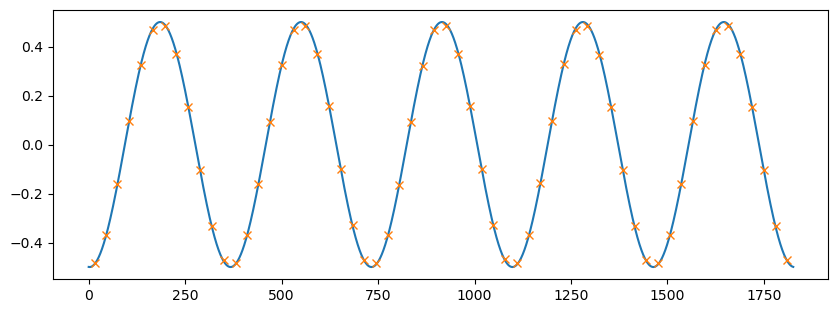

In [7]:
plt.plot(hours, calendar_start)
plt.plot(center_index, monthly_avg, 'x')

In [8]:
for i in range(4):
    print(f"Year {i+1}:")
    hours_past = int(i*period*24)
    print(f"Hourly Avg: {np.average(calendar_start[hours_past:hours_past+int(period*24)])}")
    print(days_in_month.values[int(i*12):int((i+1)*12)])
    print(f"Monthly Avg: {np.average(monthly_avg[int(i*12):int((i+1)*12)], weights=days_in_month[int(i*12):int((i+1)*12)])}")

Year 1:
Hourly Avg: -1.13991076751298e-05
[31 28 31 30 31 30 31 31 30 31 30 31]
Monthly Avg: 0.000330722650422663
Year 2:
Hourly Avg: -1.1399176597904859e-05
[31 28 31 30 31 30 31 31 30 31 30 31]
Monthly Avg: 0.0003306587500328798
Year 3:
Hourly Avg: -1.1399245286348338e-05
[31 28 31 30 31 30 31 31 30 31 30 31]
Monthly Avg: 0.0003305891347526812
Year 4:
Hourly Avg: -1.139931374044727e-05
[31 29 31 30 31 30 31 31 30 31 30 31]
Monthly Avg: -0.0010347636403450083


In [9]:
adjusted_month_length = days_in_month.copy()
adjusted_month_length.values = adjusted_month_length.values.astype("float")
year_count = 4
for i in range(year_count):
    year_months = adjusted_month_length[12 * i:12 * (i + 1)]
    if (year_months.where(year_months.isin(29), drop=True).size == 1):
        adjusted_month_length.values[i * 12] = adjusted_month_length.values[i * 12] - 3 / 8
        adjusted_month_length.values[(i + 1) * 12 - 1] = adjusted_month_length.values[(i + 1) * 12 - 1] - 3 / 8
    else:
        adjusted_month_length.values[i * 12] = adjusted_month_length.values[i * 12] + 1 / 8
        adjusted_month_length.values[(i + 1) * 12 - 1] = adjusted_month_length.values[(i + 1) * 12 - 1] + 1 / 8

In [10]:
for i in range(4):
    print(f"Year {i+1}:")
    hours_past = int(i*period*24)
    print(f"Hourly Avg: {np.average(calendar_start[hours_past:hours_past+int(period*24)])}")
    print(f"Monthly Avg: {np.average(monthly_avg[int(i*12):int((i+1)*12)], weights=adjusted_month_length.values[int(i*12):int((i+1)*12)])}")
    print(adjusted_month_length.values[int(i*12):int((i+1)*12)])

Year 1:
Hourly Avg: -1.13991076751298e-05
Monthly Avg: 4.764123660733849e-06
[31.125 28.    31.    30.    31.    30.    31.    31.    30.    31.
 30.    31.125]
Year 2:
Hourly Avg: -1.1399176597904859e-05
Monthly Avg: 4.763203163280244e-06
[31.125 28.    31.    30.    31.    30.    31.    31.    30.    31.
 30.    31.125]
Year 3:
Hourly Avg: -1.1399245286348338e-05
Monthly Avg: 4.762200341703306e-06
[31.125 28.    31.    30.    31.    30.    31.    31.    30.    31.
 30.    31.125]
Year 4:
Hourly Avg: -1.139931374044727e-05
Monthly Avg: -5.758909401256314e-05
[30.625 29.    31.    30.    31.    30.    31.    31.    30.    31.
 30.    30.625]


# Try for a March centered Average

In [11]:
month_offset = 3
for i in range(4):
    print(f"Year {i+1}:")
    day_offset = 0
    for j in range(month_offset):
        day_offset = day_offset + days_in_month[i*12+j]
    hours_past = int(i*period*24+day_offset*24)
    print(f"Hourly Avg: {np.average(calendar_start[hours_past:hours_past+int(period*24)])}")
    print(days_in_month.values[int(i*12+month_offset):int((i+1)*12+month_offset)])
    print(f"Monthly Avg: {np.average(monthly_avg[int(i*12+month_offset):int((i+1)*12+month_offset)], weights=days_in_month[int(i*12+month_offset):int((i+1)*12+month_offset)])}")

Year 1:
Hourly Avg: -7.383535099327378e-07
[30 31 30 31 31 30 31 30 31 31 28 31]
Monthly Avg: 2.2134196331401808e-05
Year 2:
Hourly Avg: -7.367211104700942e-07
[30 31 30 31 31 30 31 30 31 31 28 31]
Monthly Avg: 2.3507198226962782e-05
Year 3:
Hourly Avg: -7.350886958385061e-07
[30 31 30 31 31 30 31 30 31 31 29 31]
Monthly Avg: -6.896939708232673e-05
Year 4:
Hourly Avg: -5.374917449905207e-07
[30 31 30 31 31 30 31 30 31 31 28 31]
Monthly Avg: 2.0571324016026768e-05


In [12]:
adjusted_month_length = days_in_month.copy()
adjusted_month_length.values = adjusted_month_length.values.astype("float")
year_count = 4
for i in range(year_count):
    year_months = adjusted_month_length[12 * i+month_offset:12 * (i + 1)+month_offset]
    if (year_months.where(year_months.isin(29), drop=True).size == 1):
        adjusted_month_length.values[i * 12+month_offset] = adjusted_month_length.values[i * 12+month_offset] - 3 / 8
        adjusted_month_length.values[(i + 1) * 12 - 1+month_offset] = adjusted_month_length.values[(i + 1) * 12 - 1+month_offset] - 3 / 8
    else:
        adjusted_month_length.values[i * 12+month_offset] = adjusted_month_length.values[i * 12+month_offset] + 1 / 8
        adjusted_month_length.values[(i + 1) * 12 - 1+month_offset] = adjusted_month_length.values[(i + 1) * 12 - 1+month_offset] + 1 / 8

In [13]:
month_offset = 3
for i in range(4):
    print(f"Year {i+1}:")
    day_offset = 0
    for j in range(month_offset):
        day_offset = day_offset + days_in_month[i*12+j]
    hours_past = int(i*period*24+day_offset*24)
    print(f"Hourly Avg: {np.average(calendar_start[hours_past:hours_past+int(period*24)])}")
    print(days_in_month.values[int(i*12+month_offset):int((i+1)*12+month_offset)])
    print(f"Monthly Avg: {np.average(monthly_avg[int(i*12+month_offset):int((i+1)*12+month_offset)], weights=adjusted_month_length[int(i*12+month_offset):int((i+1)*12+month_offset)])}")

Year 1:
Hourly Avg: -7.383535099327378e-07
[30 31 30 31 31 30 31 30 31 31 28 31]
Monthly Avg: -1.0827838528216447e-06
Year 2:
Hourly Avg: -7.367211104700942e-07
[30 31 30 31 31 30 31 30 31 31 28 31]
Monthly Avg: -1.0647014249705899e-06
Year 3:
Hourly Avg: -7.350886958385061e-07
[30 31 30 31 31 30 31 30 31 31 29 31]
Monthly Avg: 3.7654978295166123e-07
Year 4:
Hourly Avg: -5.374917449905207e-07
[30 31 30 31 31 30 31 30 31 31 28 31]
Monthly Avg: -1.1033379798152672e-06


# Plot Errors for Different Month Start

In [14]:
year_errors = np.zeros((4,12))
monthly_errors = np.zeros_like(year_errors)
for k in range(12):
    month_offset = k
    for i in range(4):
        day_offset = 0
        for j in range(month_offset):
            day_offset = day_offset + days_in_month[i*12+j]
        hours_past = int(i*period*24+day_offset*24)
        year_errors[i,k] = np.average(calendar_start[hours_past:hours_past+int(period*24)])
        monthly_errors[i,k] = np.average(monthly_avg[int(i*12+month_offset):int((i+1)*12+month_offset)], weights=adjusted_month_length[int(i*12+month_offset):int((i+1)*12+month_offset)])

In [15]:
print(monthly_errors[0,:])

[ 3.63113103e-04  3.24666726e-04  2.19417799e-04 -1.08278385e-06
 -1.67542433e-04 -2.99091871e-04 -3.53851278e-04 -3.20173892e-04
 -2.04213585e-04 -4.38580874e-05  1.26786641e-04  2.52498506e-04]


In [16]:
np.arange(10)*5

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

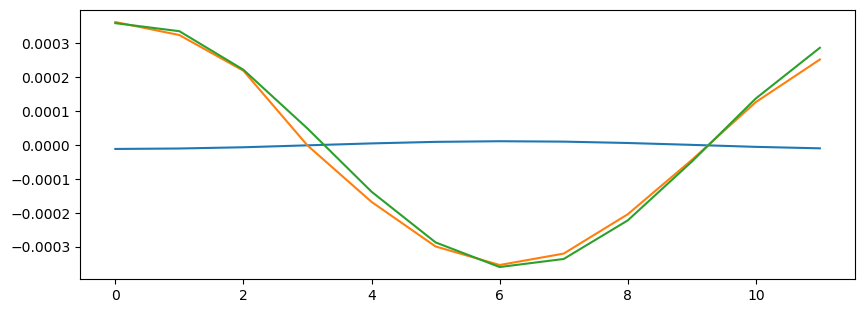

In [33]:
plt.plot(year_errors[0,:])
plt.plot(monthly_errors[0,:])
plt.plot(monthly_errors[0,0]*np.cos((np.arange(12)-/31)*2*np.pi/12))

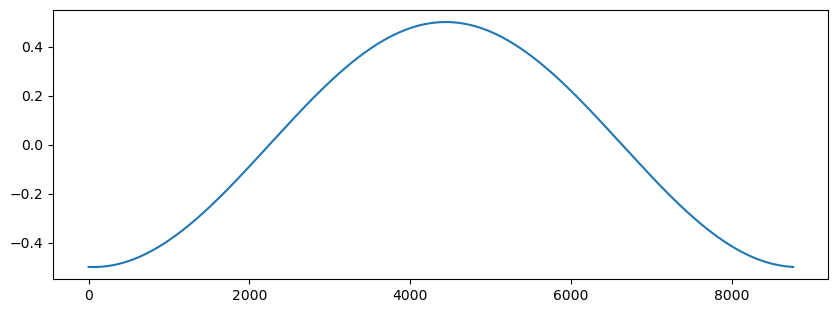

In [19]:
plt.plot(calendar_start[0:int(period*24)])

In [34]:
.2425*4

0.97

In [36]:
(1-.2425)/2

0.37875000000000003